# PYTHON API

## APARTADO A

### Localiza en el API el EndPoint que nos devuelve las categorías. 

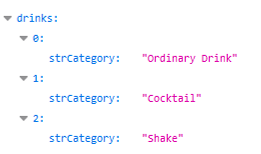

#### Realiza un programa en Python que a partir de los datos devueltos por la consulta nos muestre por pantalla los nombres de las categorías y el total de las mismas.  

In [2]:
import requests
import json

url = 'https://www.thecocktaildb.com/api/json/v1/1/list.php?c=list'

response = requests.get(url)
categorias = json.loads(response.content)
for data in categorias['drinks']:
    print(data['strCategory'])
print(f'Hay {len(categorias['drinks'])} categorias en total')


Beer
Cocktail
Cocoa
Coffee / Tea
Homemade Liqueur
Ordinary Drink
Other / Unknown
Punch / Party Drink
Shake
Shot
Soft Drink
Hay 11 categorias en total


## APARTADO B

### Localiza en el API el EndPoint que nos devuelve los cócteles pertenecientes a cada una de las categorías del ejercicio anterior. 

#### Añade al programa del ejercicio anterior una nueva funcionalidad: por cada una de las categorías genera un archivo JSON con el nombre de la misma (p.e.: ”shake.json”) que contenga todos sus cócteles –investiga en la documentación que endpoint has de utilizar-. 

In [22]:
import requests
import json

url = 'https://www.thecocktaildb.com/api/json/v1/1/list.php?c=list'
urlf = 'https://www.thecocktaildb.com/api/json/v1/1/filter.php?c='
response = requests.get(url)
categorias = json.loads(response.content)
for data in categorias['drinks']:
    print(data['strCategory'])
    nombre = data['strCategory'].replace(' ', '_')
    response = requests.get(urlf + nombre)
    categoria = json.loads(response.content)
    with open(f'{nombre.replace('/','&')}.json','w') as file:
        json.dump(categoria,file,indent=4)


print(f'Hay {len(categorias['drinks'])} categorias en total')

Beer
Cocktail
Cocoa
Coffee / Tea
Homemade Liqueur
Ordinary Drink
Other / Unknown
Punch / Party Drink
Shake
Shot
Soft Drink
Hay 11 categorias en total


#### Según vas generando los archivos, cuenta los cócteles que contiene cada categoría mostrando al final del programa por pantalla el número total de cócteles por categorías. 

In [23]:
import requests
import json

url = 'https://www.thecocktaildb.com/api/json/v1/1/list.php?c=list'
urlf = 'https://www.thecocktaildb.com/api/json/v1/1/filter.php?c='
response = requests.get(url)
categorias = json.loads(response.content)
n_bebidas = 0
for data in categorias['drinks']:
    print(data['strCategory'])
    nombre = data['strCategory'].replace(' ', '_')
    response = requests.get(urlf + nombre)
    categoria = json.loads(response.content)
    n_bebidas += len(categoria['drinks'])
    print(f'hay {len(categoria['drinks'])} bebidas en la categoría {data['strCategory']}')
    with open(f'{nombre.replace('/','&')}.json','w') as file:
        json.dump(categoria,file,indent=4)


print(f'Hay {len(categorias['drinks'])} categorias en total')
print(f'Hay {n_bebidas} cocteles en total')


Beer
hay 14 bebidas en la categoría Beer
Cocktail
hay 100 bebidas en la categoría Cocktail
Cocoa
hay 9 bebidas en la categoría Cocoa
Coffee / Tea
hay 25 bebidas en la categoría Coffee / Tea
Homemade Liqueur
hay 12 bebidas en la categoría Homemade Liqueur
Ordinary Drink
hay 100 bebidas en la categoría Ordinary Drink
Other / Unknown
hay 34 bebidas en la categoría Other / Unknown
Punch / Party Drink
hay 40 bebidas en la categoría Punch / Party Drink
Shake
hay 18 bebidas en la categoría Shake
Shot
hay 50 bebidas en la categoría Shot
Soft Drink
hay 11 bebidas en la categoría Soft Drink
Hay 11 categorias en total
Hay 413 cocteles en total


#### Realiza la misma operación que en el ejercicio B.1, pero en esta ocasión almacena todos los datos de los cócteles en un único archivo con formato csv que contendrá para cada cóctel cuatro campos: su Id, nombre, imagen y categoría. La primera fila del archivo ha de incorporar el nombre de los campos.

 

In [ ]:
import requests
import json

url = 'https://www.thecocktaildb.com/api/json/v1/1/list.php?c=list'
urlf = 'https://www.thecocktaildb.com/api/json/v1/1/filter.php?c='
response = requests.get(url)
categorias = json.loads(response.content)
with open('bebidas.csv', 'w') as file:
    file.write('Id,nombre,imagen,categoría\n')
for data in categorias['drinks']:
    print(data['strCategory'])
    nombre = data['strCategory'].replace(' ', '_')
    response = requests.get(urlf + nombre)
    categoria = json.loads(response.content)
    for bebida in categoria['drinks']:
        with open('bebidas.csv', 'w') as file:
            file.write(f'{bebida['idDrink']};{bebida['strDrink']};{bebida['strDrinkThumb']};{data['strCategory']}\n')


print(f'Hay {len(categorias['drinks'])} categorias en total')

Beer
Cocktail
Cocoa
Coffee / Tea
Homemade Liqueur
Ordinary Drink
Other / Unknown
Punch / Party Drink
Shake
Shot
Soft Drink
Hay 11 categorias en total
